## Graph

In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

In [2]:
class State(TypedDict):
    dummy_data: str


graph_builder = StateGraph(State)

In [ ]:
def node_one(state: State):
    print("Node_one")


def node_two(state: State):
    print("Node_two")


def node_three(state: State):
    print("Node_three")

In [4]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)

graph_builder.add_edge(START, "node_one")
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_edge("node_two", "node_three")
graph_builder.add_edge("node_three", END)

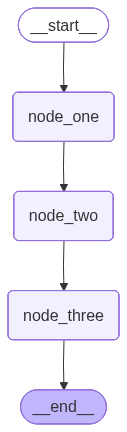

In [5]:
graph = graph_builder.compile()
graph

In [6]:
graph.invoke({})

Node_one
Node_two
Node_three


## Graph State

In [2]:
class State(TypedDict):
    dummy_data: str
    a: bool


graph_builder = StateGraph(State)

In [3]:
def node_one(state: State):
    """
    RETURN
    O → **UPDATE** state of this node (node_one)
    X → to next node (node_two)
    """
    print("Node_one", state)
    return {
        "dummy_data": "from node one",
        "a": True,
    }


def node_two(state: State):
    """
    RECEIVE state of the previous node
    """
    print("Node_two", state)
    return {"dummy_data": "from node two"}  # do not update(modify) `a`


def node_three(state: State):
    print("Node_three", state)
    return {"dummy_data": "from node three"}

In [4]:
graph_builder.add_node("aaaaa", node_one)
graph_builder.add_node("bbbbb", node_two)
graph_builder.add_node("ccccc", node_three)

graph_builder.add_edge(START, "aaaaa")
graph_builder.add_edge("aaaaa", "bbbbb")
graph_builder.add_edge("bbbbb", "ccccc")
graph_builder.add_edge("ccccc", END)

In [5]:
graph = graph_builder.compile()

result = graph.invoke(
    {
        "dummy_data": "test",
    }
)

Node_one {'dummy_data': 'test'}
Node_two {'dummy_data': 'from node one', 'a': True}
Node_three {'dummy_data': 'from node two', 'a': True}


In [7]:
result

{'dummy_data': 'from node three', 'a': True}

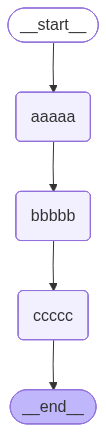

In [ ]:
graph  # langgraph server API

In [8]:
print(graph.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
  +-------+    
  | aaaaa |    
  +-------+    
      *        
      *        
      *        
  +-------+    
  | bbbbb |    
  +-------+    
      *        
      *        
      *        
  +-------+    
  | ccccc |    
  +-------+    
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   
